In [1]:
!pip install catboost
!pip install optuna

# Respiratory Diagnosis Modeling Pipeline

This notebook is organized into parts: environment setup, data loading, feature engineering, split strategy, model training, and evaluation.

Goal: build a robust multi-class classifier for respiratory diagnosis while keeping the workflow reproducible and interpretable.

In [2]:
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import optuna.visualization as vis
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from scipy.spatial.distance import cdist
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, StackingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, fbeta_score
from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold, train_test_split, cross_val_score, StratifiedGroupKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.utils import resample


## Part 1. Environment and Dependencies

Install optional packages and prepare paths for loading the dataset in Colab/local runtime.

In [3]:
@dataclass
class Config:
    random_seed: int = 42
    test_size: float = 0.2
    cv_folds: int = 5
    cvae_epochs: int = 250
    threshold_grid_low: float = 0.01
    threshold_grid_high: float = 0.7
    threshold_grid_steps: int = 70
    max_infection_threshold: float = 0.18
    use_cvae_augmentation: bool = True
    threshold_val_size: float = 0.2

config = Config()

np.random.seed(config.random_seed)
torch.manual_seed(config.random_seed)


In [4]:
REPO_PATH = Path('/content/course_paper')
DATA_REL_PATH = 'colab/data/enlarged_dataset.csv'

if REPO_PATH.exists():
    print('Repository exists, updating...')
    !git -C {REPO_PATH} fetch origin main --depth 1
    !git -C {REPO_PATH} reset --hard origin/main
else:
    print('Cloning repository...')
    !git clone --depth 1 --filter=blob:none --sparse https://github.com/incRED1bl/course_paper.git {REPO_PATH}

!git -C {REPO_PATH} sparse-checkout set {DATA_REL_PATH}

sys.path.insert(0, str(REPO_PATH))

src = REPO_PATH / DATA_REL_PATH
dst_dir = Path('/content/data')
dst_dir.mkdir(parents=True, exist_ok=True)
dst = dst_dir / 'enlarged_dataset.csv'

if src.exists():
    !cp {src} {dst}
    print(f'Dataset copied to {dst}')
else:
    raise FileNotFoundError(f'Dataset not found at {src}')

Repository exists, updating...
remote: Total 0 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
From https://github.com/incRED1bl/course_paper
 * branch            main       -> FETCH_HEAD
HEAD is now at 362f25f 87 test
Dataset copied to /content/data/enlarged_dataset.csv


## Part 2. Data Loading and Basic Cleaning

Load feature table, remove metadata columns, and keep only labeled diagnoses.

In [5]:
df = pd.read_csv('/content/course_paper/colab/data/enlarged_dataset.csv')
df.head()

,file_id,filename,relative_path,dataset,patient_id,low_freq_energy,spectral_centroid,entropy,complexity,diagnosis,zcr_variance,rmse_coeff_var,spectral_flatness,hjorth_mobility,mfcc_1_mean,mfcc_1_var,mfcc_2_mean,mfcc_2_var,mfcc_3_mean,mfcc_3_var
0,respiratory_sound_database::Respiratory_Sound_...,102_1b1_Ar_sc_Meditron.wav,Respiratory_Sound_Database/Respiratory_Sound_D...,respiratory_sound_database,2,0.697796,1253.170052,0.898144,0.087052,Healthy,2.836290e-06,0.491985,1.066887e-11,0.004815,411.830967,346.868516,95.075281,502.025984,62.562664,265.129376
1,respiratory_sound_database::Respiratory_Sound_...,103_2b2_Ar_mc_LittC2SE.wav,Respiratory_Sound_Database/Respiratory_Sound_D...,respiratory_sound_database,3,0.658031,2190.655897,0.868986,0.110194,Asthma,7.153194e-07,0.548712,1.070353e-10,0.002059,1682.543709,203.158471,59.045874,163.056532,46.305899,50.537224
2,respiratory_sound_database::Respiratory_Sound_...,104_1b1_Ar_sc_Litt3200.wav,Respiratory_Sound_Database/Respiratory_Sound_D...,respiratory_sound_database,4,0.799876,198.766348,0.701699,0.210539,COPD,2.904132e-04,0.552153,3.401299e-09,0.242970,711.369012,5449.418212,187.456382,794.549863,16.394298,1027.223633
3,respiratory_sound_database::Respiratory_Sound_...,105_1b1_Tc_sc_Meditron.wav,Respiratory_Sound_Database/Respiratory_Sound_D...,respiratory_sound_database,5,0.396047,2338.788742,0.933559,0.059629,URTI,5.539475e-04,0.530288,2.041829e-07,0.113771,1730.755780,2982.187645,153.423952,2439.313522,71.694684,120.153273
4,respiratory_sound_database::Respiratory_Sound_...,106_2b1_Pl_mc_LittC2SE.wav,Respiratory_Sound_Database/Respiratory_Sound_D...,respiratory_sound_database,6,0.814369,1303.551393,0.921622,0.069483,COPD,3.560188e-05,0.784495,4.228126e-09,0.018662,1617.788718,138.173383,118.308106,214.539517,38.049638,173.949463


In [6]:
display(df['diagnosis'].value_counts())

,count
diagnosis,
COPD,465
Pneumonia,291
Asthma,289
Healthy,159
Bronchial,104
URTI,13
Bronchiectasis,7
Bronchiolitis,6
LRTI,2


In [7]:
meta_cols = ['filename', 'file_id', 'relative_path', 'dataset']
df = df.drop(columns=meta_cols, errors='ignore')

if 'diagnosis' not in df.columns:
    raise ValueError("Expected 'diagnosis' column in dataset")

df = df[df['diagnosis'].notna()]
df = df[df['diagnosis'] != 'Unknown']

infection_labels = {'Pneumonia', 'URTI', 'LRTI', 'Bronchiolitis'}
copd_labels = {'COPD', 'Asthma', 'Bronchiectasis', 'Bronchial'}

def map_to_3class(label):
    if label == 'Healthy':
        return 'Healthy'
    if label in infection_labels:
        return 'Infection'
    if label in copd_labels:
        return 'COPD'
    return np.nan

df['diagnosis_3class'] = df['diagnosis'].apply(map_to_3class)
dropped_unmapped = int(df['diagnosis_3class'].isna().sum())
df = df.dropna(subset=['diagnosis_3class']).copy()

display(df['diagnosis_3class'].value_counts())
df.head()


,count
diagnosis_3class,
COPD,865
Infection,312
Healthy,159


,patient_id,low_freq_energy,spectral_centroid,entropy,complexity,diagnosis,zcr_variance,rmse_coeff_var,spectral_flatness,hjorth_mobility,mfcc_1_mean,mfcc_1_var,mfcc_2_mean,mfcc_2_var,mfcc_3_mean,mfcc_3_var,diagnosis_3class
0,2,0.697796,1253.170052,0.898144,0.087052,Healthy,2.836290e-06,0.491985,1.066887e-11,0.004815,411.830967,346.868516,95.075281,502.025984,62.562664,265.129376,Healthy
1,3,0.658031,2190.655897,0.868986,0.110194,Asthma,7.153194e-07,0.548712,1.070353e-10,0.002059,1682.543709,203.158471,59.045874,163.056532,46.305899,50.537224,COPD
2,4,0.799876,198.766348,0.701699,0.210539,COPD,2.904132e-04,0.552153,3.401299e-09,0.242970,711.369012,5449.418212,187.456382,794.549863,16.394298,1027.223633,COPD
3,5,0.396047,2338.788742,0.933559,0.059629,URTI,5.539475e-04,0.530288,2.041829e-07,0.113771,1730.755780,2982.187645,153.423952,2439.313522,71.694684,120.153273,Infection
4,6,0.814369,1303.551393,0.921622,0.069483,COPD,3.560188e-05,0.784495,4.228126e-09,0.018662,1617.788718,138.173383,118.308106,214.539517,38.049638,173.949463,COPD


## Part 3. Feature Engineering and Visuals

Create relational acoustic features and class-distance features to enrich representation before model training. And functions to visualize data.

In [8]:
def engineer_relational_features(df):
    new_df = df.copy()

    def get_numeric(col_name):
        if col_name in new_df.columns:
            return pd.to_numeric(new_df[col_name], errors='coerce').fillna(0.0)
        return None

    low = get_numeric('low_freq_energy')
    complexity = get_numeric('complexity')
    centroid = get_numeric('spectral_centroid')
    entropy = get_numeric('entropy')

    flatness = get_numeric('spectral_flatness')
    mobility = get_numeric('hjorth_mobility')

    new_df['entropy_complexity_interaction'] = entropy * complexity

    def safe_divide(num, den):
        den_clean = den.copy()
        min_non_zero = den_clean[den_clean > 0].min() if (den_clean > 0).any() else 1e-3
        min_non_zero = max(min_non_zero, 1e-3)
        den_clean[den_clean == 0] = min_non_zero

        result = num / den_clean
        return result.clip(lower=-10000.0, upper=10000.0)

    if flatness is not None:
        new_df['centroid_flatness_ratio'] = safe_divide(centroid, flatness)

    if mobility is not None:
        new_df['mobility_complexity_ratio'] = safe_divide(mobility, complexity)

    peak = get_numeric('peak_frequency')
    if peak is not None:
        new_df['centroid_peak_diff'] = centroid - peak
        new_df['centroid_peak_ratio'] = safe_divide(centroid, peak)

    new_df = new_df.replace([np.inf, -np.inf], np.nan).fillna(0)
    return new_df


In [9]:
def add_class_distance_features(train_df, test_df, feature_cols, target_col='diagnosis'):
    usable_cols = []
    for col in feature_cols:
        if col in train_df.columns and col in test_df.columns:
            if pd.api.types.is_numeric_dtype(train_df[col]):
                usable_cols.append(col)

    if not usable_cols:
        raise ValueError('No numeric feature columns available for class-distance features.')

    dist_scaler = StandardScaler()
    train_scaled = dist_scaler.fit_transform(train_df[usable_cols])
    test_scaled = dist_scaler.transform(test_df[usable_cols])

    centroids = train_df.groupby(target_col)[usable_cols].mean()
    centroids_scaled = dist_scaler.transform(centroids)

    dist_train = cdist(train_scaled, centroids_scaled, metric='euclidean')
    dist_test = cdist(test_scaled, centroids_scaled, metric='euclidean')

    dist_cols = [f'dist_to_{cls}' for cls in centroids.index]
    df_dist_train = pd.DataFrame(dist_train, columns=dist_cols, index=train_df.index)
    df_dist_test = pd.DataFrame(dist_test, columns=dist_cols, index=test_df.index)

    return pd.concat([train_df, df_dist_train], axis=1), pd.concat([test_df, df_dist_test], axis=1)

In [10]:
class CVAE(nn.Module):
    def __init__(self, feature_dim, class_dim, latent_dim=4):
        super(CVAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(feature_dim + class_dim, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim * 2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + class_dim, 32),
            nn.ReLU(),
            nn.Linear(32, feature_dim)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, c):
        inputs = torch.cat([x, c], dim=1)
        h = self.encoder(inputs)
        mu, logvar = torch.chunk(h, 2, dim=1)

        logvar = torch.clamp(logvar, min=-15.0, max=15.0)

        z = self.reparameterize(mu, logvar)
        z_cond = torch.cat([z, c], dim=1)
        return self.decoder(z_cond), mu, logvar


In [11]:
def train_cvae_module(X_train, y_enc, epochs=250):
    feature_dim = X_train.shape[1]
    class_dim = len(np.unique(y_enc))

    model = CVAE(feature_dim, class_dim)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    x_tensor = torch.FloatTensor(X_train.values)
    c_tensor = torch.FloatTensor(np.eye(class_dim)[y_enc])

    dataset = TensorDataset(x_tensor, c_tensor)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for batch_x, batch_c in dataloader:
            recon_x, mu, logvar = model(batch_x, batch_c)

            recon_loss = nn.functional.mse_loss(recon_x, batch_x, reduction='sum') / batch_x.size(0)
            kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / batch_x.size(0)
            loss = recon_loss + kld_loss

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)

            optimizer.step()

    return model


In [12]:
def generate_borderline_samples(model, class_idx, num_samples, class_dim, feature_names, sigma=1.5, seed=42):
    model.eval()
    gen = torch.Generator()
    gen.manual_seed(seed)
    with torch.no_grad():
        c = torch.zeros(num_samples, class_dim)
        c[:, class_idx] = 1
        z = torch.randn(num_samples, 4, generator=gen) * sigma
        z_cond = torch.cat([z, c], dim=1)
        samples = model.decoder(z_cond).numpy()
    return pd.DataFrame(samples, columns=feature_names)

In [13]:
def plot_augmentation_quality(original_df, synthetic_df, target_class_name, le, feature_to_plot='spectral_centroid'):
    if target_class_name not in le.classes_:
        print(f'Skip plot: class {target_class_name} is not present in current dataset.')
        return

    idx = list(le.classes_).index(target_class_name)
    orig_cls = original_df[original_df['target'] == idx].drop(columns=['target', 'is_synthetic', 'patient_id'], errors='ignore')
    synth_cls = synthetic_df[synthetic_df['target'] == idx].drop(columns=['target', 'is_synthetic', 'patient_id'], errors='ignore')

    if orig_cls.empty or synth_cls.empty:
        print(f'Skip plot: not enough data for class {target_class_name}.')
        return

    if feature_to_plot not in orig_cls.columns:
        print(f'Skip density plot: feature {feature_to_plot} is absent.')
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    pca = PCA(n_components=2)
    pca.fit(orig_cls)

    orig_pca = pca.transform(orig_cls)
    synth_pca = pca.transform(synth_cls)

    axes[0].scatter(orig_pca[:, 0], orig_pca[:, 1], alpha=0.7, label='Original', color='teal', s=50)
    axes[0].scatter(synth_pca[:, 0], synth_pca[:, 1], alpha=0.3, label='Synthetic (CVAE)', color='orange', s=20)
    axes[0].set_title(f'PCA Projection for {target_class_name}')
    axes[0].legend()

    sns.kdeplot(orig_cls[feature_to_plot], ax=axes[1], label='Original', color='teal', fill=True, alpha=0.3)
    sns.kdeplot(synth_cls[feature_to_plot], ax=axes[1], label='Synthetic', color='orange', fill=True, alpha=0.3)
    axes[1].set_title(f'Distribution of {feature_to_plot} ({target_class_name})')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


In [14]:
def plot_correlation_diff(original_df, synthetic_df, target_class_name, le):
    if target_class_name not in le.classes_:
        print(f'Skip correlation plot: class {target_class_name} is not present.')
        return

    idx = list(le.classes_).index(target_class_name)
    orig_cls = original_df[original_df['target'] == idx].drop(columns=['target', 'is_synthetic', 'patient_id'], errors='ignore')
    synth_cls = synthetic_df[synthetic_df['target'] == idx].drop(columns=['target', 'is_synthetic', 'patient_id'], errors='ignore')

    if orig_cls.empty or synth_cls.empty:
        print(f'Skip correlation plot: insufficient data for class {target_class_name}.')
        return

    cols = orig_cls.columns[:10]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(orig_cls[cols].corr(), cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0], cbar=False)
    axes[0].set_title(f'Original Correlations ({target_class_name})')

    sns.heatmap(synth_cls[cols].corr(), cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
    axes[1].set_title(f'Synthetic Correlations ({target_class_name})')

    plt.tight_layout()
    plt.show()


In [15]:
def macro_sensitive_predict(probs, labels_list, threshold_sick=0.12):
    name_to_idx = {name: i for i, name in enumerate(labels_list)}

    infection_cluster = ['Infection']
    obstructive_cluster = ['COPD']

    inf_indices = [name_to_idx[n] for n in infection_cluster if n in name_to_idx]
    obs_indices = [name_to_idx[n] for n in obstructive_cluster if n in name_to_idx]

    final_preds = np.argmax(probs, axis=1)

    for i in range(len(probs)):
        max_inf_prob = np.max(probs[i][inf_indices]) if inf_indices else 0
        max_obs_prob = np.max(probs[i][obs_indices]) if obs_indices else 0

        if max_inf_prob > threshold_sick:
            final_preds[i] = inf_indices[np.argmax(probs[i][inf_indices])]
        elif max_obs_prob > threshold_sick:
            final_preds[i] = obs_indices[np.argmax(probs[i][obs_indices])]

    return final_preds

In [16]:
def plot_dual_confusion_matrix(cm, labels, title='Confusion Matrix', subtitle=''):
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax[0],
        xticklabels=labels,
        yticklabels=labels,
    )
    ax[0].set_title(f'{title}\n{subtitle}' if subtitle else title)

    row_sums = cm.sum(axis=1, keepdims=True)
    cm_perc = np.divide(cm.astype(float), row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
    sns.heatmap(
        cm_perc,
        annot=True,
        fmt='.2%',
        cmap='Greens',
        ax=ax[1],
        xticklabels=labels,
        yticklabels=labels,
    )
    ax[1].set_title(f'Normalized {title} (Recall %)')

    plt.show()

## Part 4. Train/Test Split Strategy

Use stratified 80/20 split on diagnosis labels, then derive distance-based features from train centroids and apply them to test set.

This prevents leakage: class centroids are fitted on train data only.

In [17]:
df_eng = engineer_relational_features(df)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=config.random_seed)
train_idx, test_idx = next(sgkf.split(df_eng, df_eng['diagnosis_3class'], groups=df_eng['patient_id']))

X_train_raw = df_eng.iloc[train_idx].copy()
X_test_raw = df_eng.iloc[test_idx].copy()

feature_block = X_train_raw.drop(columns=['diagnosis', 'diagnosis_3class', 'patient_id'], errors='ignore')
numeric_cols = feature_block.select_dtypes(include=[np.number]).columns.tolist()

X_train_base = X_train_raw[numeric_cols + ['diagnosis_3class']].copy()
X_test_base = X_test_raw[numeric_cols + ['diagnosis_3class']].copy()

le = LabelEncoder()
y_train_enc = le.fit_transform(X_train_base['diagnosis_3class'])
y_test_enc = le.transform(X_test_base['diagnosis_3class'])

X_train_final = X_train_base.drop(columns=['diagnosis_3class'])
X_test_final = X_test_base.drop(columns=['diagnosis_3class'])

print(f'Cleaned Pipeline: {len(numeric_cols)} base features ready for modeling.')


Cleaned Pipeline: 17 base features ready for modeling.


In [18]:
assert len(X_train_final) == len(y_train_enc), 'Train X/y length mismatch.'
assert len(X_test_final) == len(y_test_enc), 'Test X/y length mismatch.'
assert 'diagnosis' not in X_train_final.columns, 'Target leakage: diagnosis column found in training features.'

print('Train shape:', X_train_final.shape, '| Test shape:', X_test_final.shape)
print('Encoded train class counts:\n', pd.Series(y_train_enc).value_counts().sort_index())

Train shape: (1069, 17) | Test shape: (267, 17)
Encoded train class counts:
 0    695
1    124
2    250
Name: count, dtype: int64


## Part 5. Optional CVAE Augmentation

Train CVAE on tabular features. Synthetic sample generation is optional and currently left commented to keep baseline reproducible.

In [19]:
if config.use_cvae_augmentation:
    print("CVAE augmentation is enabled.")
    cvae_imputer = SimpleImputer(strategy='median')
    cvae_scaler = StandardScaler()

    X_train_clean = cvae_imputer.fit_transform(X_train_final)
    X_train_scaled_cvae = cvae_scaler.fit_transform(X_train_clean)
    X_train_scaled_df = pd.DataFrame(X_train_scaled_cvae, columns=X_train_final.columns)

    cvae_train_df = X_train_scaled_df.copy()
    cvae_train_df['target'] = y_train_enc

    max_size = cvae_train_df['target'].value_counts().max()
    balanced_classes = []
    for cls_idx in cvae_train_df['target'].unique():
        cls_data = cvae_train_df[cvae_train_df['target'] == cls_idx]
        cls_upsampled = resample(cls_data, replace=True, n_samples=max_size, random_state=config.random_seed)
        balanced_classes.append(cls_upsampled)

    cvae_train_balanced = pd.concat(balanced_classes).reset_index(drop=True)
    X_cvae_fit = cvae_train_balanced.drop(columns=['target'])
    y_cvae_fit = cvae_train_balanced['target'].values

    cvae_model_scaled = train_cvae_module(
        X_cvae_fit,
        y_cvae_fit,
        epochs=config.cvae_epochs,
    )

    rare_classes = ['Infection', 'Healthy']
    target_count = 300
    synthetic_list = []

    for cls_name in rare_classes:
        if cls_name in le.classes_:
            idx = list(le.classes_).index(cls_name)
            gen_scaled = generate_borderline_samples(
                cvae_model_scaled, idx, target_count, len(le.classes_), X_train_final.columns, sigma=1.8, seed=config.random_seed
            )
            gen_raw = cvae_scaler.inverse_transform(gen_scaled)
            gen_df = pd.DataFrame(gen_raw, columns=X_train_final.columns)
            gen_df['target'] = idx
            gen_df['is_synthetic'] = 1
            synthetic_list.append(gen_df)

    if synthetic_list:
        df_synthetic = pd.concat(synthetic_list, axis=0).reset_index(drop=True)
    else:
        df_synthetic = pd.DataFrame(columns=list(X_train_final.columns) + ['target', 'is_synthetic'])

    df_synthetic['patient_id'] = np.arange(len(df_synthetic)) + 999999

    train_full = pd.DataFrame(X_train_clean, columns=X_train_final.columns)
    train_full['target'] = y_train_enc
    train_full['is_synthetic'] = 0
    train_full['patient_id'] = X_train_raw['patient_id'].values

    df_augmented_final = pd.concat([train_full, df_synthetic], axis=0).reset_index(drop=True)
    X_train_aug = df_augmented_final.drop(columns=['target', 'is_synthetic', 'patient_id'])
    y_train_aug = df_augmented_final['target'].values
    patient_groups_array = df_augmented_final['patient_id'].values

    print(f'Original samples: {len(train_full)}')
    print(f'Synthetic samples: {len(df_synthetic)}')

else:
    print('CVAE augmentation disabled. Using original training split only.')
    train_full = pd.DataFrame(X_train_final.copy())
    train_full['target'] = y_train_enc
    train_full['is_synthetic'] = 0
    df_synthetic = pd.DataFrame(columns=list(X_train_final.columns) + ['target', 'is_synthetic'])
    X_train_aug = X_train_final.copy()
    y_train_aug = y_train_enc.copy()
    patient_groups_array = X_train_raw['patient_id'].values


X_train_aug_with_target = X_train_aug.copy()
X_train_aug_with_target['diagnosis_3class'] = le.inverse_transform(y_train_aug)

X_test_with_target = X_test_final.copy()
X_test_with_target['diagnosis_3class'] = le.inverse_transform(y_test_enc)

X_train_dist, X_test_dist = add_class_distance_features(
    X_train_aug_with_target,
    X_test_with_target,
    numeric_cols,
    target_col='diagnosis_3class'
)


X_train_to_fit = X_train_dist.drop(columns=['diagnosis_3class'], errors='ignore')
y_train_to_fit = y_train_aug.copy()
X_test_final = X_test_dist.drop(columns=['diagnosis_3class'], errors='ignore')

print(f'Final training shape with distance features: {X_train_to_fit.shape}')


CVAE augmentation is enabled.
Original samples: 1069
Synthetic samples: 600
Final training shape with distance features: (1669, 20)


Augmentation quality checks:



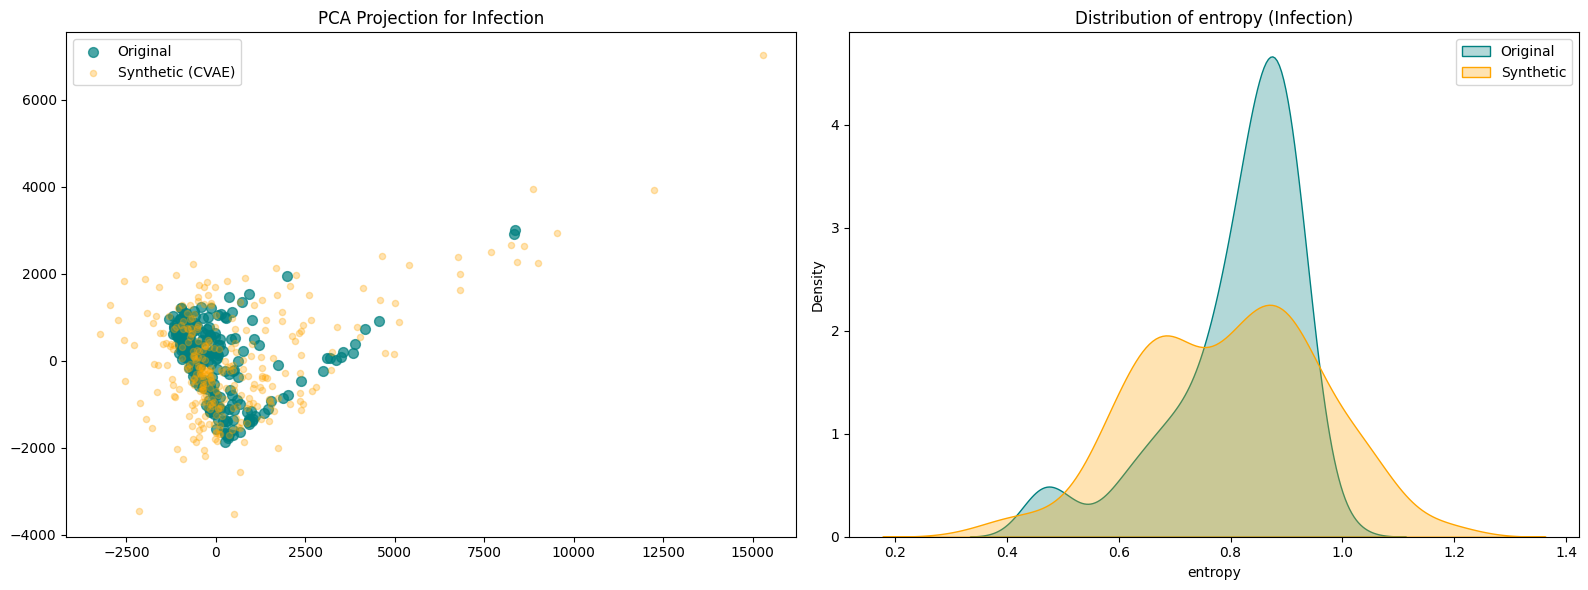

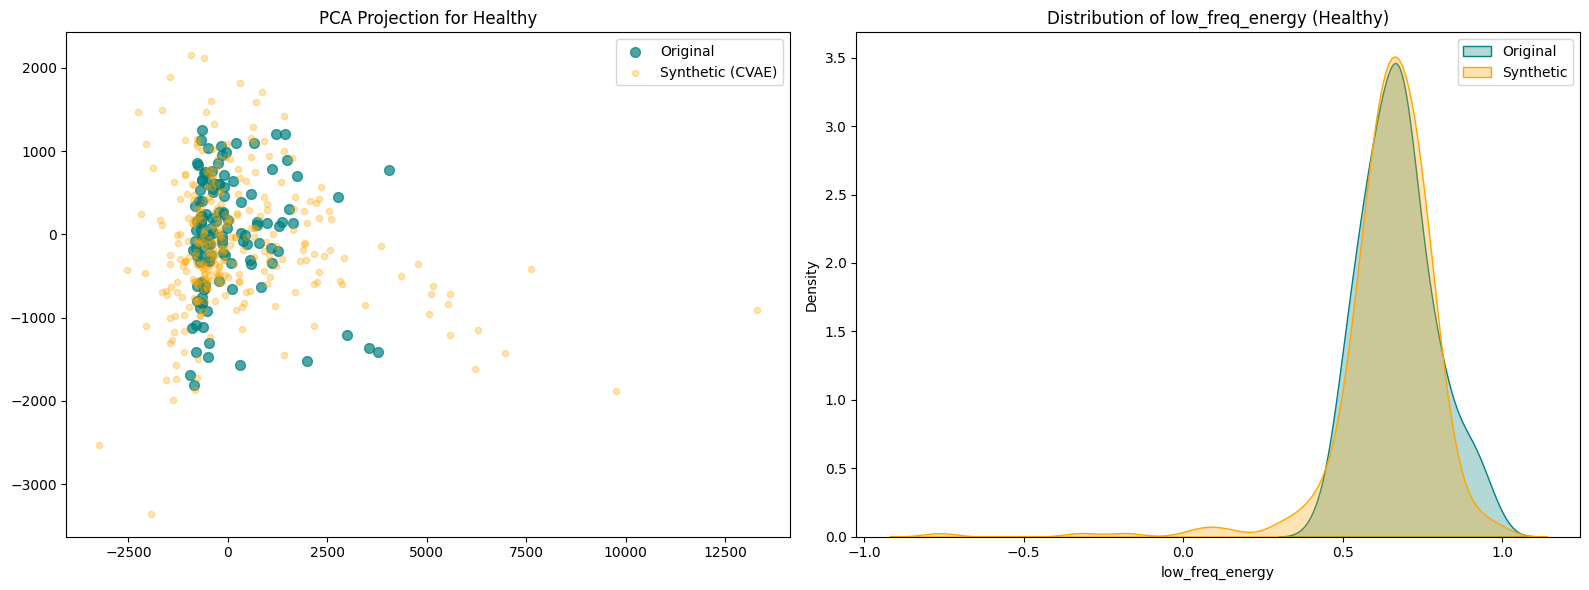

In [20]:
print('Augmentation quality checks:')
print()

plot_augmentation_quality(train_full, df_synthetic, 'Infection', le, feature_to_plot='entropy')
plot_augmentation_quality(train_full, df_synthetic, 'Healthy', le, feature_to_plot='low_freq_energy')

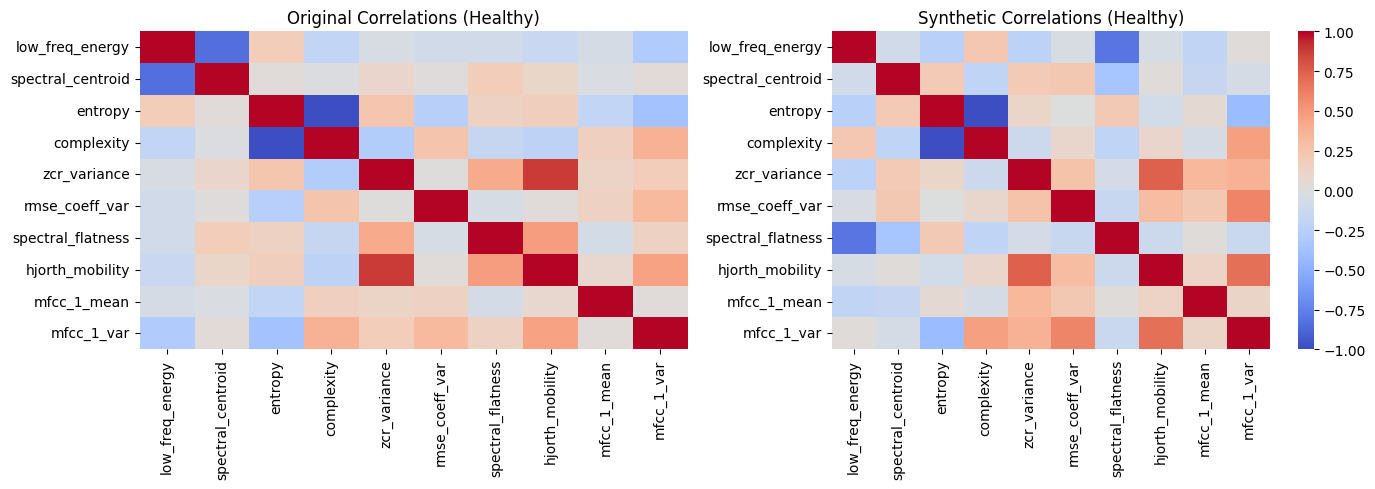

In [21]:
plot_correlation_diff(train_full, df_synthetic, 'Healthy', le)

## Part 6. Preprocessing and Label Construction

Impute missing values, scale features, and build hierarchical binary targets used by specialist expert models.

In [22]:
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_imputed = imputer.fit_transform(X_train_to_fit)
X_test_imputed = imputer.transform(X_test_final)

X_train_scaled_full = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=X_train_to_fit.columns)
X_test_scaled_full = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_train_to_fit.columns)

X_train_scaled = X_train_scaled_full.copy()
X_test_scaled = X_test_scaled_full.copy()

class_to_idx = {name: i for i, name in enumerate(le.classes_)}
required = {'Healthy', 'COPD', 'Infection'}
missing_required = required - set(class_to_idx)
if missing_required:
    raise ValueError(f'Missing required 3-class labels in training data: {missing_required}')

ordered_labels_3 = ['Healthy', 'COPD', 'Infection']
train_names = le.inverse_transform(y_train_to_fit)
test_names = le.inverse_transform(y_test_enc)

y_train_3class = np.array([ordered_labels_3.index(name) for name in train_names])
y_test_3class = np.array([ordered_labels_3.index(name) for name in test_names])

In [23]:
assert not np.isnan(X_train_scaled.values).any(), 'NaN values present in X_train_scaled.'
assert not np.isnan(X_test_scaled.values).any(), 'NaN values present in X_test_scaled.'

print('Sanity check passed: scaled matrices contain no NaN values.')

Sanity check passed: scaled matrices contain no NaN values.


In [24]:
level0 = [
    ('rf', RandomForestClassifier(n_estimators=353, max_depth=13, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('cat', CatBoostClassifier(iterations=300, depth=3, learning_rate=0.003165941570593106, silent=True, random_state=42)),
    ('lgbm', lgb.LGBMClassifier(n_estimators=311, learning_rate=0.08995883450766122, random_state=42, verbose=-1, n_jobs=-1))
]

middle_tier = [
    ('xgb', xgb.XGBClassifier(n_estimators=126, max_depth=3, learning_rate=0.004384173139750956, random_state=42, n_jobs=-1)),
    ('et', ExtraTreesClassifier(n_estimators=234, max_depth=5, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('svc', SVC(probability=True, class_weight='balanced', C=0.4014118324790612, random_state=42))
]

meta = StackingClassifier(estimators=middle_tier, final_estimator=LogisticRegression(class_weight='balanced', max_iter=3000), cv=3, n_jobs=-1)

model_multi_3 = StackingClassifier(estimators=level0, final_estimator=meta, cv=3, n_jobs=-1)

model_multi_3.fit(X_train_scaled, y_train_3class)


StackingClassifier(cv=3,
                   estimators=[('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=13,
                                                       n_estimators=353,
                                                       n_jobs=-1,
                                                       random_state=42)),
                               ('cat',
                                CatBoostClassifier(depth=3, iterations=300, learning_rate=0.003165941570593106, random_state=42, silent=True)),
                               ('lgbm',
                                LGBMClassifier(learning_rate=0.08995883450766122,
                                               n_estimators=311, n_jobs=-1,
                                               rando...
                                                                                 n_estimators=126,
                                                                                 n_jobs=-1,
                                                                                 num_parallel_tree=None, ...)),
                                                                  ('et',
                                                                   ExtraTreesClassifier(class_weight='balanced',
                                                                                        max_depth=5,
                                                                                        n_estimators=234,
                                                                                        n_jobs=-1,
                                                                                        random_state=42)),
                                                                  ('svc',
                                                                   SVC(C=0.4014118324790612,
                                                                       class_weight='balanced',
                                                                       probability=True,
                                                                       random_state=42))],
                                                      final_estimator=LogisticRegression(class_weight='balanced',
                                                                                         max_iter=3000),
                                                      n_jobs=-1),
                   n_jobs=-1)

## Part 7. Stacking, Thresholding, and Cross-Validation

Train specialists and final 3-class stack, then evaluate using macro-F1 and confusion matrices in stratified CV.

In [25]:
skf_cv = StratifiedGroupKFold(n_splits=config.cv_folds, shuffle=True, random_state=config.random_seed)
total_cm = np.zeros((3, 3), dtype=int)
fold_f1 = []

print('Running optimized 5-fold CV on the pyramid Stack...')

for fold, (train_idx_cv, val_idx_cv) in enumerate(skf_cv.split(X_train_to_fit, y_train_3class, groups=patient_groups_array), 1):
    X_fold_train = X_train_to_fit.iloc[train_idx_cv]
    X_fold_val = X_train_to_fit.iloc[val_idx_cv]
    y_fold_train_3 = y_train_3class[train_idx_cv]
    y_fold_val_3 = y_train_3class[val_idx_cv]

    cv_imputer = SimpleImputer(strategy='median')
    cv_scaler = StandardScaler()

    X_fold_train_sc = pd.DataFrame(
        cv_scaler.fit_transform(cv_imputer.fit_transform(X_fold_train)),
        columns=X_fold_train.columns,
    )
    X_fold_val_sc = pd.DataFrame(
        cv_scaler.transform(cv_imputer.transform(X_fold_val)),
        columns=X_fold_train.columns,
    )

    m_stack_cv = clone(model_multi_3)
    m_stack_cv.fit(X_fold_train_sc, y_fold_train_3)

    y_pred = m_stack_cv.predict(X_fold_val_sc)

    total_cm += confusion_matrix(y_fold_val_3, y_pred, labels=[0, 1, 2])
    fold_f1.append(f1_score(y_fold_val_3, y_pred, average='macro'))

    print(f'Fold {fold} done.')

print(f'\nCV macro-F1 mean: {np.mean(fold_f1):.4f} +/- {np.std(fold_f1):.4f}')

Running optimized 5-fold CV on the pyramid Stack...
Fold 1 done.
Fold 2 done.
Fold 3 done.
Fold 4 done.
Fold 5 done.

CV macro-F1 mean: 0.8766 +/- 0.0098


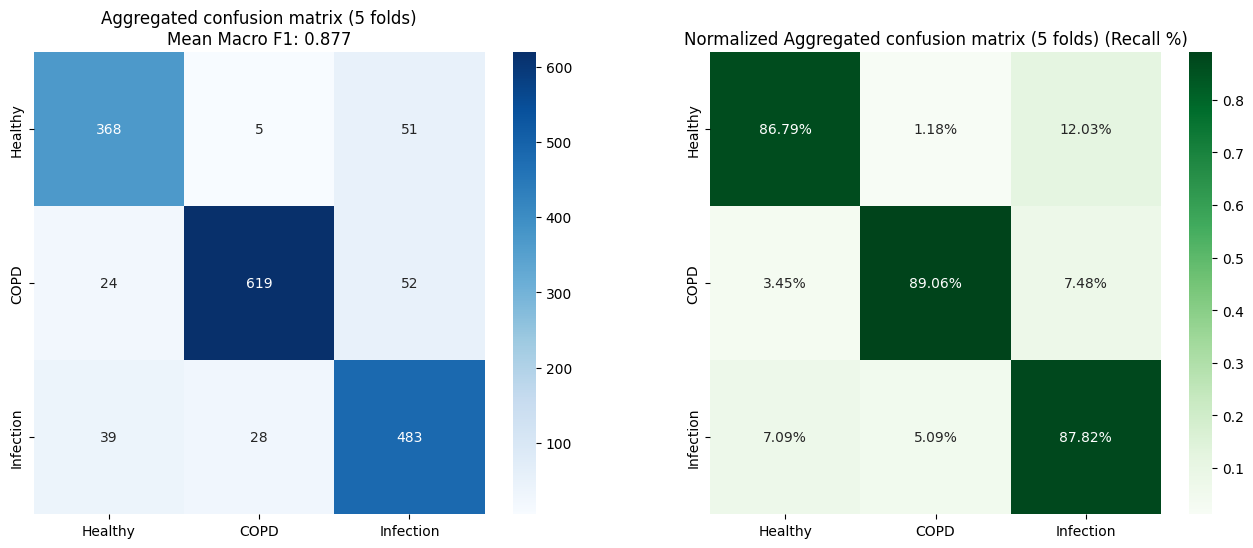

In [26]:
plot_dual_confusion_matrix(
    total_cm,
    ordered_labels_3,
    title='Aggregated confusion matrix (5 folds)',
    subtitle=f'Mean Macro F1: {np.mean(fold_f1):.3f}'
)

## Part 8. Held-Out Test Evaluation

Evaluate the final stacked system on the 20% held-out test split after model training and threshold calibration.

Held-out test macro-F1: 0.7941158514687926



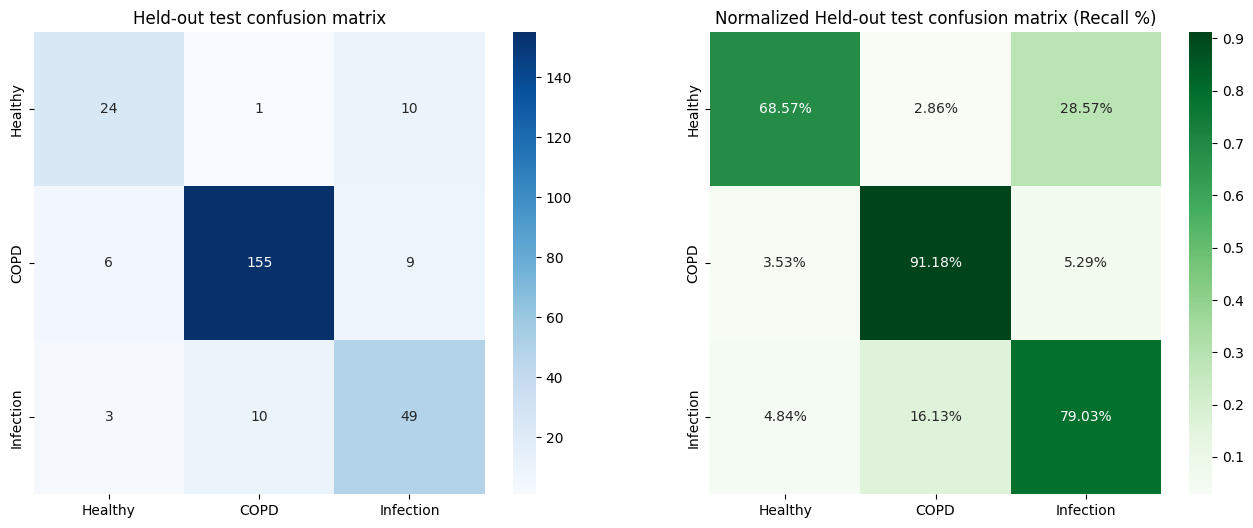

In [27]:
y_test_pred_3 = model_multi_3.predict(X_test_scaled)

print('Held-out test macro-F1:', f1_score(y_test_3class, y_test_pred_3, average='macro'))
print()

cm_test = confusion_matrix(y_test_3class, y_test_pred_3, labels=[0, 1, 2])
plot_dual_confusion_matrix(cm_test, ordered_labels_3, title='Held-out test confusion matrix')

## Part 8.5 Rigorous Threshold Validation

To ensure our reporting metrics are not optimistically biased, we split the training data once more to create a dedicated validation set. We retrain the model, tune the decision threshold on this validation set using the `macro_sensitive_predict` function, and finally evaluate on the untouched test set.

In [28]:
X_train_sub, X_val_thresh, y_train_sub, y_val_thresh = train_test_split(
    X_train_scaled, y_train_3class,
    test_size=config.threshold_val_size,
    stratify=y_train_3class,
    random_state=config.random_seed
)

print(f"Sub-training set shape: {X_train_sub.shape}")
print(f"Threshold tuning validation set shape: {X_val_thresh.shape}")

print("\nRetraining model on sub-training set to prevent data leakage during thresholding...")
model_multi_3_thresh = clone(model_multi_3)
model_multi_3_thresh.fit(X_train_sub, y_train_sub)
print("Model retrained successfully.")

Sub-training set shape: (1335, 20)
Threshold tuning validation set shape: (334, 20)

Retraining model on sub-training set to prevent data leakage during thresholding...
Model retrained successfully.


In [29]:
val_probs = model_multi_3_thresh.predict_proba(X_val_thresh)

best_threshold = 0.12
best_f2 = -1.0

low = config.threshold_grid_low
high = config.threshold_grid_high
steps = config.threshold_grid_steps
thresholds = np.linspace(low, high, steps)

for thresh in thresholds:
    val_preds = macro_sensitive_predict(val_probs, ordered_labels_3, threshold_sick=thresh)
    f2 = fbeta_score(y_val_thresh, val_preds, beta=2, average='macro')

    if f2 > best_f2:
        best_f2 = f2
        best_threshold = thresh

best_val_preds = macro_sensitive_predict(val_probs, ordered_labels_3, threshold_sick=best_threshold)
best_weighted_f2 = fbeta_score(y_val_thresh, best_val_preds, beta=2, average='weighted')

print(f"Optimal Threshold found on Validation Set: {best_threshold:.4f}")
print(f"Validation Macro-F2 at optimal threshold: {best_f2:.4f}")
print(f"Validation Weighted-F2 at optimal threshold: {best_weighted_f2:.4f}")

Optimal Threshold found on Validation Set: 0.3700
Validation Macro-F2 at optimal threshold: 0.8906
Validation Weighted-F2 at optimal threshold: 0.8975


Held-out Test Macro-F1: 0.8415
Held-out Test Macro-F2: 0.8391
Held-out Test Weighted-F2: 0.8911



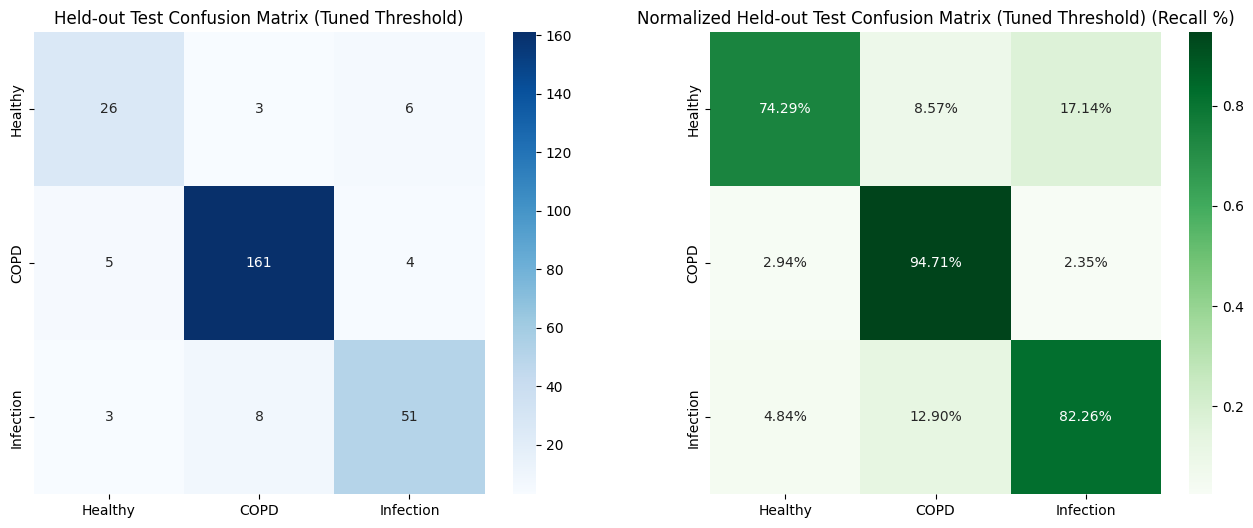

In [30]:
test_probs = model_multi_3_thresh.predict_proba(X_test_scaled)
final_test_preds = macro_sensitive_predict(test_probs, ordered_labels_3, threshold_sick=best_threshold)

print(f'Held-out Test Macro-F1: {f1_score(y_test_3class, final_test_preds, average="macro"):.4f}')
print(f'Held-out Test Macro-F2: {fbeta_score(y_test_3class, final_test_preds, beta=2, average="macro"):.4f}')
print(f'Held-out Test Weighted-F2: {fbeta_score(y_test_3class, final_test_preds, beta=2, average="weighted"):.4f}')
print()

cm_tuned = confusion_matrix(y_test_3class, final_test_preds, labels=[0, 1, 2])
plot_dual_confusion_matrix(cm_tuned, ordered_labels_3, title='Held-out Test Confusion Matrix (Tuned Threshold)')

In [31]:
print("95% Confidence Intervals for Recall (Held-out Test Set):")
print("-" * 60)

conf_matrix = confusion_matrix(y_test_3class, final_test_preds, labels=[0, 1, 2])

for i, class_name in enumerate(ordered_labels_3):
    tp = conf_matrix[i, i]
    support = conf_matrix[i, :].sum()
    recall = tp / support if support > 0 else 0.0

    z = 1.96
    margin_of_error = z * np.sqrt((recall * (1 - recall)) / support)

    ci_lower = max(0.0, recall - margin_of_error)
    ci_upper = min(1.0, recall + margin_of_error)

    print(f"{class_name:10s} - Recall: {recall:.4f} | 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}] (Support: {support})")

95% Confidence Intervals for Recall (Held-out Test Set):
------------------------------------------------------------
Healthy    - Recall: 0.7429 | 95% CI: [0.5981, 0.8877] (Support: 35)
COPD       - Recall: 0.9471 | 95% CI: [0.9134, 0.9807] (Support: 170)
Infection  - Recall: 0.8226 | 95% CI: [0.7275, 0.9177] (Support: 62)


## Part 9. Optuna Hyperparameter Tuning

Tuning the stacking model's base estimators and the meta-learner using Optuna.

In [32]:
# def objective(trial):

#     xgb_params = {
#         'n_estimators': trial.suggest_int('xgb_n_estimators', 100, 400),
#         'max_depth': trial.suggest_int('xgb_max_depth', 3, 8),
#         'learning_rate': trial.suggest_float('xgb_lr', 1e-3, 0.1, log=True),
#     }

#     lgbm_params = {
#         'n_estimators': trial.suggest_int('lgbm_n_estimators', 100, 400),
#         'learning_rate': trial.suggest_float('lgbm_lr', 1e-3, 0.1, log=True),
#         'verbose': -1
#     }

#     et_params = {
#         'n_estimators': trial.suggest_int('et_n_estimators', 100, 400),
#         'max_depth': trial.suggest_int('et_max_depth', 5, 20),
#         'class_weight': 'balanced'
#     }

#     rf_params = {
#         'n_estimators': trial.suggest_int('rf_n_estimators', 100, 400),
#         'max_depth': trial.suggest_int('rf_max_depth', 5, 20),
#         'class_weight': 'balanced'
#     }

#     svc_params = {
#         'C': trial.suggest_float('svc_C', 0.1, 10.0, log=True),
#         'probability': True,
#         'class_weight': 'balanced'
#     }

#     cat_params = {
#         'iterations': trial.suggest_int('cat_iterations', 100, 400),
#         'depth': trial.suggest_int('cat_depth', 3, 8),
#         'learning_rate': trial.suggest_float('cat_lr', 1e-3, 0.1, log=True),
#         'silent': True
#     }


#     meta_params = {
#         'n_estimators': trial.suggest_int('meta_n_estimators', 50, 250),
#         'max_depth': trial.suggest_int('meta_max_depth', 2, 7),
#         'class_weight': 'balanced'
#     }

#     level0_tuned = [
#         ('xgb', xgb.XGBClassifier(**xgb_params, random_state=config.random_seed)),
#         ('lgbm', lgb.LGBMClassifier(**lgbm_params, random_state=config.random_seed)),
#         ('et', ExtraTreesClassifier(**et_params, random_state=config.random_seed)),
#         ('rf', RandomForestClassifier(**rf_params, random_state=config.random_seed)),
#         ('svc', SVC(**svc_params, random_state=config.random_seed)),
#         ('cat', CatBoostClassifier(**cat_params, random_state=config.random_seed))
#     ]

#     meta_learner_tuned = RandomForestClassifier(**meta_params, random_state=config.random_seed)

#     stack = StackingClassifier(
#         estimators=level0_tuned,
#         final_estimator=meta_learner_tuned,
#         cv=3,
#         stack_method='predict_proba',
#         n_jobs=-1
#     )


#     skf_opt = StratifiedKFold(n_splits=3, shuffle=True, random_state=config.random_seed)
#     scores = cross_val_score(stack, X_train_scaled, y_train_3class, cv=skf_opt, scoring='f1_macro', n_jobs=1)

#     return scores.mean()

# print('Starting Optuna Tuning (100 trials or 3600 seconds)...')
# study_name = 'stacking_tuning'
# storage_name = 'sqlite:///optuna_study.db'
# study = optuna.create_study(study_name=study_name, storage=storage_name, direction='maximize', load_if_exists=True)
# study.optimize(objective, n_trials=100, timeout=3600)

# print('\nBest trial:')
# trial = study.best_trial
# print(f'  Macro-F1 Score: {trial.value:.4f}')
# print('  Best Parameters: ')
# for key, value in trial.params.items():
#     print(f'    {key}: {value}')


# vis.plot_optimization_history(study)
# vis.plot_param_importances(study)